# Prueba de Clasificación Supervisada — Requerimientos

Aplica el modelo supervisado entrenado en `Supervisado_Requerimientos.ipynb` sobre un CSV nuevo.

**Input:**  `requerimientos_2026-06-04_12-21-57.csv`  
**Output:** `prueba_clasificacion_supervisada_requerimientos.csv`

## 1. Librerías

In [107]:
import os
import re
import glob
import random
import unicodedata
import warnings
from pathlib import Path
from datetime import timedelta
from dateutil.relativedelta import relativedelta

import numpy as np
import pandas as pd
import spacy
from tqdm.auto import tqdm
import joblib

warnings.filterwarnings('ignore')
tqdm.pandas()

RAIZ = Path(os.getcwd()).parent
DIR_DATA    = RAIZ / 'Data'
DIR_MODELOS = RAIZ / 'Modelos'
print('Raíz del proyecto:', RAIZ)

Raíz del proyecto: c:\ASIGNADOR\Asignador


## 2. Carga del CSV de Requerimientos

In [108]:
ruta_csv = DIR_DATA / 'requerimientos_2026-06-04_12-21-57.csv'

for enc in ('utf-8-sig', 'latin-1'):
    for sep in (',', ';'):
        try:
            df = pd.read_csv(ruta_csv, encoding=enc, sep=sep)
            print(f'Leído con encoding={enc}, sep={sep!r}')
            break
        except (UnicodeDecodeError, pd.errors.ParserError):
            continue
    else:
        continue
    break

print(f'Tickets cargados: {len(df)}')
print(f'Columnas: {list(df.columns)}')
df.head(3)

Leído con encoding=latin-1, sep=';'
Tickets cargados: 61
Columnas: ['number', 'state', 'ref_sc_req_item.requested_for', 'requested_for.vip', 'requested_for.email', 'requested_for.title', 'requested_for.company', 'assigned_to', 'assignment_group', 'short_description', 'cat_item.sc_catalogs', 'description', 'opened_at']


,number,state,ref_sc_req_item.requested_for,requested_for.vip,requested_for.email,requested_for.title,requested_for.company,assigned_to,assignment_group,short_description,cat_item.sc_catalogs,description,opened_at
0,RITM0925366,En proceso,CARLA BEATRIZ ZAMBRANO ORTEGA,falso,cabzambr@pichincha.com,ADMINISTRADOR SERVICIOS,Banco Pichincha C.A.,JOSEPH ANGELO HERRERA GUERRA,TEC_TCS_BANCS,Requerimientos de información relacionados a Bancs y BancsLink,TI,su gentil ayuda no permite sacar en sistema bancs el reporte de certificados a plazo disponibles a la fecha en ag cc38,03/06/2026 17:09:46
1,RITM0893373,En proceso,ROMEO OCTAVIO MEJIA MANZANO,falso,romejiam@pichincha.com,INGENIERO GESTION IDENTIDADES,NTTDATA,EDWIN ANIBAL CATAGNA CARVAJAL,TEC_TCS_BANCS,Requerimientos de información relacionados a Bancs y BancsLink,TI,su ayuda incluyendo en el menú 99 las opciones las opciones 21097 y 21098. se adjuntan autorizaciones.,11/05/2026 11:22:44
2,RITM0926296,En proceso,PATRICIA SOLEDAD CUENCA MACAS,falso,pcuenca@pichincha.com,OFICIAL COMERCIAL Y SERVICIOS,Banco Pichincha C.A.,LUIS SEBASTIAN CATOTA CAIZALUISA,TEC_TCS_BANCS,Requerimientos de información relacionados a Bancs y BancsLink,TI,SU AYUDA CON LA MODIFICACION DE LA FORMA NUMERADA DE ENTREGADA AL CLIENTE A DESTRUCCION EN BANCSLINKS # DE FORMA NUMERADA 1493050 SE ADJUNTA ACTA DE DESTRUCUION,04/06/2026 12:01:43


## 3. Carga del Modelo Entrenado

Se busca automáticamente el modelo más reciente en la carpeta `Modelos/`.

In [109]:
# Buscar el modelo y vectorizer más recientes
modelos_disponibles   = sorted(glob.glob(str(DIR_MODELOS / 'modelo_req_*.joblib')))
vectorizers_disponibles = sorted(glob.glob(str(DIR_MODELOS / 'vectorizer_req_*.joblib')))

if not modelos_disponibles:
    raise FileNotFoundError(f'No se encontró ningún modelo en {DIR_MODELOS}. '
                             'Ejecuta primero Supervisado_Requerimientos.ipynb.')

ruta_modelo     = modelos_disponibles[-1]       # el más reciente (orden alfabético = cronológico)
ruta_vectorizer = vectorizers_disponibles[-1]

print(f'Modelo:     {ruta_modelo}')
print(f'Vectorizer: {ruta_vectorizer}')

modelo     = joblib.load(ruta_modelo)
vectorizer = joblib.load(ruta_vectorizer)
print('Cargados correctamente.')

Modelo:     c:\ASIGNADOR\Asignador\Modelos\modelo_req_Random_Forest_20260615.joblib
Vectorizer: c:\ASIGNADOR\Asignador\Modelos\vectorizer_req_tfidf_20260615.joblib


Cargados correctamente.


## 4. Pipeline de Limpieza de Texto

Mismo pipeline que en `Supervisado_Requerimientos.ipynb` (spaCy + boilerplate removal).

### 4.1 normalize_text

In [110]:
nlp_es = spacy.load('es_core_news_md', disable=['ner', 'parser', 'senter'])
_PLACEHOLDERS = {'url', 'email', 'fecha', 'num_largo', 'num'}

def normalize_text(texto):
    if pd.isna(texto):
        return ''
    t = str(texto).strip().lower()
    t = unicodedata.normalize('NFKC', t)
    t = re.sub(r'(https?://\S+|www\.\S+)', ' url ', t)
    t = re.sub(r'\b[\w\.-]+@[\w\.-]+\.\w+\b', ' email ', t)
    t = re.sub(r'\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b', ' fecha ', t)
    t = re.sub(r'\b\d{7,}\b', ' num_largo ', t)
    t = re.sub(r'\b\d+\b', ' num ', t)
    t = re.sub(r'[_\-=/\\|()[\]{},;:]+', ' ', t)
    t = re.sub(r'[^\w\s]', ' ', t)
    t = re.sub(r'\s+', ' ', t).strip()
    t = re.sub(r'(.)\1{3,}', ' ', t)
    t = re.sub(r'\s+', ' ', t).strip()
    doc = nlp_es(t)
    lemmas = []
    for token in doc:
        if token.is_space:
            continue
        raw = token.lower_.strip()
        if raw in _PLACEHOLDERS:
            lemmas.append(raw)
        else:
            lemma = token.lemma_.lower().strip()
            if lemma:
                lemmas.append(lemma)
    t = ' '.join(lemmas)
    t = unicodedata.normalize('NFKD', t).encode('ascii', 'ignore').decode('utf-8', errors='ignore')
    t = re.sub(r'[^a-z0-9\s]', ' ', t)
    t = re.sub(r'\s+', ' ', t).strip()
    return t

### 4.2 strip_boilerplate

In [111]:
boilerplate_patterns = [
    r'\brequerimientos?\s+de\s+informacion\s+relacionados?\s+a\s+bancs?\s+y\s+bancslinks?\b',
    r'\batencion\s+solicitudes?\s+bancs?\s+y\s+bancslinks?\b',
    r'\bestimad[oa]s?\b', r'\bbuen[oa]s?\s+d[ii]as?\b',
    r'\bbuen[oa]s?\s+tardes?\b', r'\bbuen[oa]s?\s+noches?\b',
    r'\bbuen\s+d[ii]a\b',
    r'^\s*estimad[oa]s?\b', r'^\s*buen[oa]s?\s+d[ii]as\b',
    r'^\s*buen[oa]s?\s+tardes\b', r'^\s*buen[oa]s?\s+noches\b',
    r'\bespero\s+se\s+encuentren\s+bien\b',
    r'\bpor\s+favor\b', r'\bfavor\b', r'\bfavor\s+con\b',
    r'\bsu\s+gentil\s+ayuda\b', r'\bsu\s+ayuda\b',
    r'\bsu\s+gentil\s+apoyo\b', r'\bsu\s+apoyo\b',
    r'\bgentil\s+apoyo\b', r'\bfavor\s+su\s+ayuda\b',
    r'\bpor\s+favor\s+su\s+ayuda\s+con\b', r'\bpor\s+favor\s+su\s+apoyo\s+con\b',
    r'\bpor\s+favor\s+apoyar\b', r'\bpor\s+favor\s+ayudar\b',
    r'\bsu\s+gentil\s+apoyo\s+con\b', r'\bsu\s+ayuda\s+con\b',
    r'\bapoyo\s+con\b', r'\bayuda\s+con\b',
    r'\batenta?\s+a\s+sus\s+comentarios\b', r'\bquedo\s+atent[oa]\b',
    r'\bde\s+antemano\b', r'\bles\s+agradezco\b',
    r'\bagradezco\s+su\s+ayuda\b',
    r'\bcordial(?:es)?\s+saludos\b', r'\bsaludos?\s+cordiales?\b',
    r'\bsaludos?\b', r'\bgracias\b', r'\badjunto\b',
    r'\besperar\s+se\s+encontrar\s+bien\b', r'\badjuntar\b',
    r'\bquedar\s+atent[oa]\b', r'\bcordial(?:es)?\s+saludo[s]?\b',
    r'\bgracia[s]?\b', r'\ble[s]?\s+agradecer\b',
    r'\bagradecer\s+su\s+ayuda\b',
    r'\batento?\s+a\s+su[s]?\s+comentario[s]?\b',
]
boilerplate_regex = re.compile('|'.join(boilerplate_patterns))
prefix_regex = re.compile(
    r'^(con|con el|con la|con los|con las|para|sobre|del|de la|de los|de las)\s+'
)

def strip_boilerplate(texto):
    if pd.isna(texto):
        return ''
    t = str(texto)
    for _ in range(6):
        t_new = boilerplate_regex.sub(' ', t)
        t_new = re.sub(r'\s+', ' ', t_new).strip()
        if t_new == t:
            break
        t = t_new
    for _ in range(4):
        t_new = prefix_regex.sub('', t).strip()
        if t_new == t:
            break
        t = t_new
    return re.sub(r'\s+', ' ', t).strip()

### 4.3 construir_texto_final

In [112]:
def es_texto_informativo(txt, min_tokens=4):
    if pd.isna(txt):
        return False
    return len(str(txt).strip().split()) >= min_tokens

def construir_texto_final(row):
    d = row['desc_core']  if pd.notna(row['desc_core'])  else ''
    s = row['short_core'] if pd.notna(row['short_core']) else ''
    d_ok = es_texto_informativo(d)
    s_ok = es_texto_informativo(s)
    if d_ok and s_ok:
        return (d + ' ' + s).strip()
    if d_ok:
        return d.strip()
    if s_ok:
        return s.strip()
    return ''

## 5. Aplicar Limpieza de Texto

In [113]:
print('Normalizando short_description...')
df['short_norm'] = df['short_description'].progress_apply(normalize_text)

print('Normalizando description...')
df['desc_norm'] = df['description'].progress_apply(normalize_text)

df['short_core'] = df['short_norm'].apply(strip_boilerplate)
df['desc_core']  = df['desc_norm'].apply(strip_boilerplate)

df['texto_limpio'] = df.apply(construir_texto_final, axis=1)

sin_texto = (df['texto_limpio'] == '').sum()
print(f'\nLimpieza completada.')
print(f'Tickets con texto válido: {len(df) - sin_texto} / {len(df)}')
print(f'Tickets sin texto útil:   {sin_texto}')

Normalizando short_description...


100%|██████████| 61/61 [00:00<00:00, 131.97it/s]


Normalizando description...


100%|██████████| 61/61 [00:02<00:00, 29.74it/s]



Limpieza completada.
Tickets con texto válido: 60 / 61
Tickets sin texto útil:   1


## 6. Clasificación

In [114]:
# Vectorizar con el mismo TF-IDF del entrenamiento
X_nuevo = vectorizer.transform(df['texto_limpio'])

# Predecir
df['clasificacion'] = modelo.predict(X_nuevo)

# Confianza
if hasattr(modelo, 'predict_proba'):
    proba = modelo.predict_proba(X_nuevo)
    df['confianza'] = proba.max(axis=1).round(4)
    umbral = 0.40
else:
    scores = modelo.decision_function(X_nuevo)
    exp_s  = np.exp(scores - scores.max(axis=1, keepdims=True))
    proba  = exp_s / exp_s.sum(axis=1, keepdims=True)
    df['confianza'] = proba.max(axis=1).round(4)
    umbral = 0.10

df['requiere_revision'] = df['confianza'] < umbral

# Tickets sin texto: se marcan como 'revision' con confianza 0
mask_sin_texto = df['texto_limpio'] == ''
df.loc[mask_sin_texto, 'clasificacion']     = 'revision'
df.loc[mask_sin_texto, 'confianza']         = 0.0
df.loc[mask_sin_texto, 'requiere_revision'] = True

print('Distribución de clasificaciones asignadas:')
print(df['clasificacion'].value_counts().to_string())

Distribución de clasificaciones asignadas:
clasificacion
estados_cuenta                        40
opciones_menu_bancslinks               5
operaciones_credito_amortizacion       4
debito_automatico_pagos                4
formas_numeradas                       3
revision                               1
cheques_activos_devolucion             1
soporte_transacciones_produccion       1
consolidacion_productos_cif            1
comprobantes_pignoracion_impresion     1


Total clasificados:            60
Sin texto (sin_texto):         1
Confianza baja (< 0.4): 29
Confianza media:               0.409


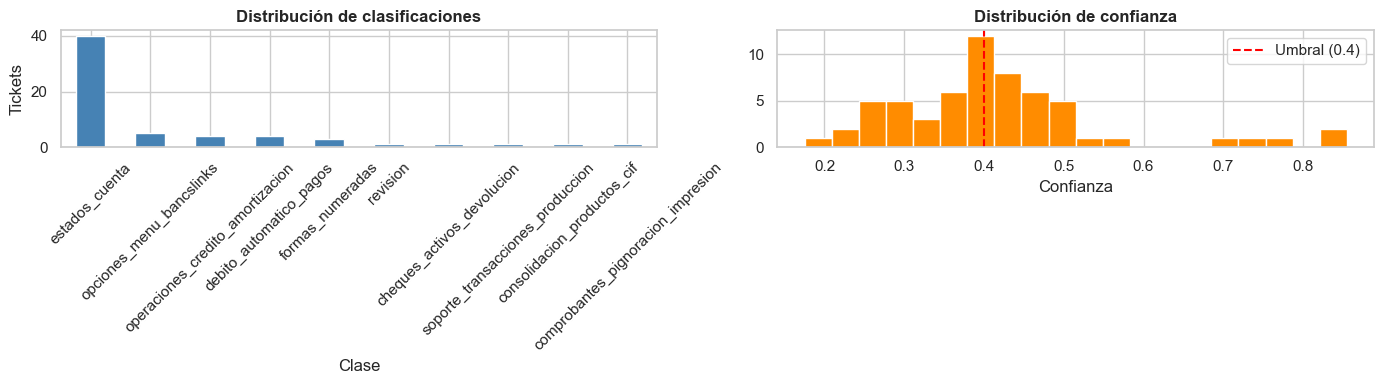

In [115]:
print(f'Total clasificados:            {(~mask_sin_texto).sum()}')
print(f'Sin texto (sin_texto):         {mask_sin_texto.sum()}')
print(f'Confianza baja (< {umbral}): {df["requiere_revision"].sum()}')
print(f'Confianza media:               {df["confianza"].mean():.3f}')

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['clasificacion'].value_counts().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Distribución de clasificaciones', fontweight='bold')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Tickets')
axes[0].tick_params(axis='x', rotation=45)

axes[1].hist(df.loc[~mask_sin_texto, 'confianza'], bins=20,
             color='darkorange', edgecolor='white')
axes[1].axvline(umbral, color='red', linestyle='--', label=f'Umbral ({umbral})')
axes[1].set_title('Distribución de confianza', fontweight='bold')
axes[1].set_xlabel('Confianza')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Exportar Resultados

In [116]:
def calcular_fecha_resolucion(opened_at_str):
    try:
        fecha_asignacion = pd.to_datetime(opened_at_str, format='%d/%m/%Y %H:%M:%S')
    except Exception:
        return None

    fecha_base      = fecha_asignacion + relativedelta(months=1)
    dias_resta      = random.randint(0, 5)
    fecha_calculada = fecha_base - timedelta(days=dias_resta)

    if fecha_calculada.weekday() < 5:
        fecha_final = fecha_calculada.date()
    else:
        dias_a_viernes   = fecha_calculada.weekday() - 4
        dias_a_lunes     = 7 - fecha_calculada.weekday()
        viernes_anterior = fecha_calculada - timedelta(days=dias_a_viernes)
        lunes_siguiente  = fecha_calculada + timedelta(days=dias_a_lunes)
        fecha_min        = fecha_base - timedelta(days=5)

        if lunes_siguiente > fecha_base:
            fecha_final = viernes_anterior.date()
        elif viernes_anterior < fecha_min:
            fecha_final = lunes_siguiente.date()
        else:
            fecha_final = viernes_anterior.date()

    return fecha_asignacion.replace(year=fecha_final.year, month=fecha_final.month, day=fecha_final.day)

tiene_opened_at = 'opened_at' in df.columns

if tiene_opened_at:
    random.seed(42)
    df['fecha_resolucion'] = df['opened_at'].apply(calcular_fecha_resolucion)
    print('Muestra de fechas calculadas:')
    print(df[['number', 'opened_at', 'fecha_resolucion']].head(5).to_string())
else:
    print('Columna "opened_at" no encontrada — se omite el cálculo de fecha_resolucion.')

Muestra de fechas calculadas:
        number            opened_at    fecha_resolucion
0  RITM0925366  03/06/2026 17:09:46 2026-06-29 17:09:46
1  RITM0893373  11/05/2026 11:22:44 2026-06-11 11:22:44
2  RITM0926296  04/06/2026 12:01:43 2026-07-03 12:01:43
3  RITM0914986  01/06/2026 01:11:38 2026-06-26 01:11:38
4  RITM0912302  28/05/2026 12:10:18 2026-06-26 12:10:18


In [ ]:
cols_export = ['number', 'short_description', 'description',
               'clasificacion', 'confianza', 'requiere_revision']

if tiene_opened_at:
    cols_export.insert(3, 'opened_at')
    cols_export.append('fecha_resolucion')

df_export = df[cols_export].copy()

ruta_salida = DIR_DATA / 'prueba_clasificacion_supervisada_requerimientos_tickets_requerimientos_2026-06-04_12-21-57_v5.csv'
df_export.to_csv(ruta_salida, index=False, encoding='utf-8-sig')

print(f'Archivo exportado: {ruta_salida}')
print(f'Total filas: {len(df_export)}')
df_export.head(10)

Archivo exportado: c:\ASIGNADOR\Asignador\Data\prueba_clasificacion_supervisada_requerimientos_tickets_requerimientos_2026-06-04_12-21-57_v4.csv
Total filas: 61


,number,short_description,description,opened_at,clasificacion,confianza,requiere_revision,fecha_resolucion
0,RITM0925366,Requerimientos de información relacionados a Bancs y BancsLink,su gentil ayuda no permite sacar en sistema bancs el reporte de certificados a plazo disponibles a la fecha en ag cc38,03/06/2026 17:09:46,estados_cuenta,0.4086,False,2026-06-29 17:09:46
1,RITM0893373,Requerimientos de información relacionados a Bancs y BancsLink,su ayuda incluyendo en el menú 99 las opciones las opciones 21097 y 21098. se adjuntan autorizaciones.,11/05/2026 11:22:44,opciones_menu_bancslinks,0.8350,False,2026-06-11 11:22:44
2,RITM0926296,Requerimientos de información relacionados a Bancs y BancsLink,SU AYUDA CON LA MODIFICACION DE LA FORMA NUMERADA DE ENTREGADA AL CLIENTE A DESTRUCCION EN BANCSLINKS # DE FORMA NUMERADA 1493050 SE ADJUNTA ACTA DE DESTRUCUION,04/06/2026 12:01:43,formas_numeradas,0.4550,False,2026-07-03 12:01:43
3,RITM0914986,Requerimientos de información relacionados a Bancs y BancsLink,Soporte Bancs Junio 2026,01/06/2026 01:11:38,estados_cuenta,0.4825,False,2026-06-26 01:11:38
4,RITM0912302,Requerimientos de información relacionados a Bancs y BancsLink,"Solicitamos amablemente su colaboración proporcionando el archivo Glif con la siguiente información: Fechas: 27 de Mayo 2026 Journals: 274655, 273455, 274655",28/05/2026 12:10:18,estados_cuenta,0.4902,False,2026-06-26 12:10:18
5,RITM0907798,Requerimientos de información relacionados a Bancs y BancsLink,SE SOLICITA SABER EL MOTIVO POR EL CUAL LA CUENTA # 2100061923 PRESENTE DIFERENCIA ENTRE EL SALDO CONTABLE Y DISPONIBLE TICKET REFERENCIA: RITM0793901,22/05/2026 17:08:35,operaciones_credito_amortizacion,0.3516,True,2026-06-19 17:08:35
6,RITM0898085,Requerimientos de información relacionados a Bancs y BancsLink,SE SOLICITA ELCAMBIO DE ESTADO A DESTRUIDO A LAS CHEQUERAS DE LAS SIGUIENTES CUENTAS CANCELADAS: CTA#3124511004 CHEQUERA DESDE 182 -220 / CTA# 3116817104 CHEQUERA DESDE 2670-2680. ADJUNTO ACTA DE ...,14/05/2026 14:53:42,formas_numeradas,0.4000,False,2026-06-12 14:53:42
7,RITM0914150,Requerimientos de información relacionados a Bancs y BancsLink,Se requiere el número de cuentas y el la suma del saldo disponible de las cuentas corrientes que ganan intereses de manera mensual desde enero 2025 hasta la fecha.,29/05/2026 15:23:04,estados_cuenta,0.4007,False,2026-06-26 15:23:04
8,RITM0905182,Requerimientos de información relacionados a Bancs y BancsLink,"Se requiere el detalle de los sobregiros a plazo otorgados en agencias ( no por cámara de compensación) del periodo comprendido desde el 5 de enero 2026 al 30 de abril 2026, Por favor se requiere ...",20/05/2026 17:24:41,estados_cuenta,0.4058,False,2026-06-15 17:24:41
9,RITM0898808,Requerimientos de información relacionados a Bancs y BancsLink,"Revisión del proceso de generación del archivo BNC_CLIENTES, solución raíz a los problemas: 1. Caracteres especiales 2.Envío correcto de los Clientes ELIMINADOS 3. Archivo con registros incompletos",15/05/2026 09:35:57,estados_cuenta,0.3480,True,2026-06-15 09:35:57
